In [20]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
#import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import jax.numpy as jnp
import jax
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")
output_data_ex1 = os.path.join(base_dir,  "Experiment1_Pedagogical", "optimisation", "output_data")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

save_dir = os.path.join(base_dir, "graphs")


In [21]:
from types import SimpleNamespace

def load_run(data_dir, fname):
    """Load a results .npz file and return its arrays as jnp arrays in a namespace."""
    raw = np.load(os.path.join(data_dir, fname), allow_pickle=True)
    ns = SimpleNamespace()
    for key in raw:
        try:
            setattr(ns, key, jnp.array(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns


# Error metrics

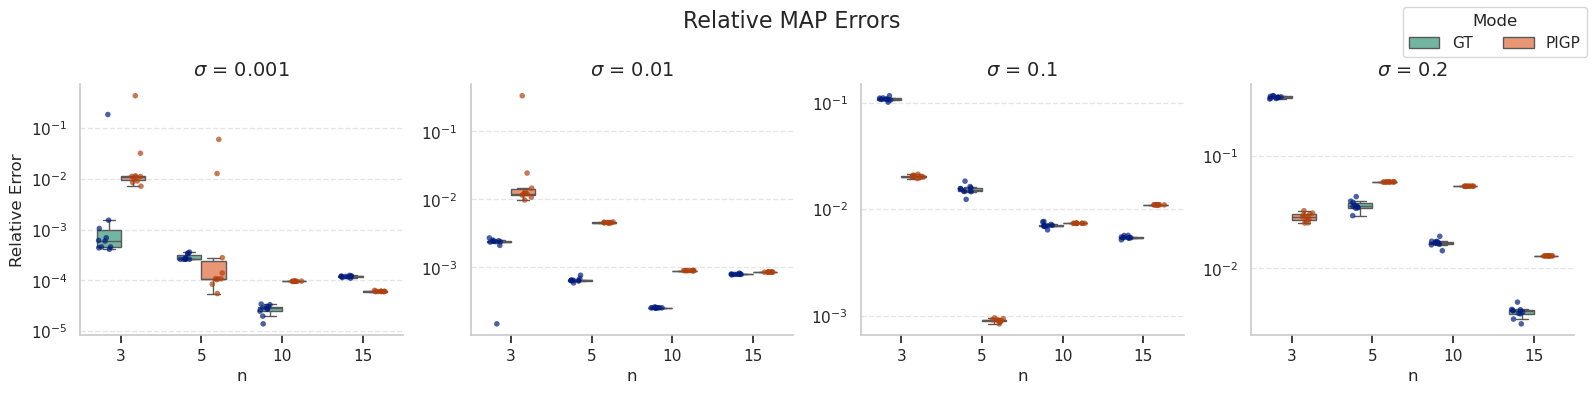

In [19]:
runs = 10
data_mode = ["extra_npoints_extra_sigma", "standard", ]
sigma_list = [0.001, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 15]#, 5, 10]#,  30, 50]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 1, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            data_dir = os.path.join(output_data_ex1, data_mode[j])

            for run in range(runs):
                fname = f"Ex1_n{npoints}_sigma{sigma:.2f}_{mode}_{run}.npz"
                try:
                    data = load_run(data_dir, fname)
                
                    all_AE[n_idx, sigma_idx, j, 0, run] = abs(data.learned_parameters - 2)/2
                except:  pass
               


# --- reshape all_AE into long-form dataframe ---
records = []

display_n = ["3", "5", "10", "15"]
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for run in range(runs):
                ae = all_AE[n_idx, sigma_idx, mode_idx, 0, run]
                records.append({
                    "n": display_n[n_idx],
                    "sigma": sigma,
                    "mode": mode,
                    "data_mode": data_mode[mode_idx],
                    "AE": ae
                })

df = pd.DataFrame.from_records(records)

# categorical ordering
df["n"] = pd.Categorical(df["n"], categories=display_n, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
sns.set(style="whitegrid")

# --- plotting (exact same style as Ex2 inverse) ---
g = sns.FacetGrid(
    df,
    col="sigma",
    height=4,
    aspect=1.,
    sharey=False,
    margin_titles=False
)

def box_and_points(data, **kwargs):
    ax = plt.gca()
    sns.boxplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, width=0.6, showfliers=False, palette="Set2", ax=ax
    )
    sns.stripplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, jitter=0.15, size=4, alpha=0.7, palette="dark", ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

g.map_dataframe(box_and_points)

# single legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles[:2], labels[:2], title="Mode", ncol=2)

# formatting: sigma in the subtitle (no parameter name)
nrows, ncols = g.axes.shape
for i in range(nrows):
    for j in range(ncols):
        ax = g.axes[i, j]
        ax.set_yscale("log")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.set_title(rf"$\sigma$ = {g.col_names[j]}", fontsize=14)
        # keep x ticks on every panel, tick labels only on the bottom row
        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=(i == nrows - 1))

g.set_axis_labels("n", "Relative Error")

g.figure.suptitle("Relative MAP Errors", fontsize=16)
g.figure.tight_layout()
#g.figure.subplots_adjust(top=0.90)

plt.savefig(os.path.join(save_dir, "Ex1_inverse.pdf"), bbox_inches="tight")

# Forward problem

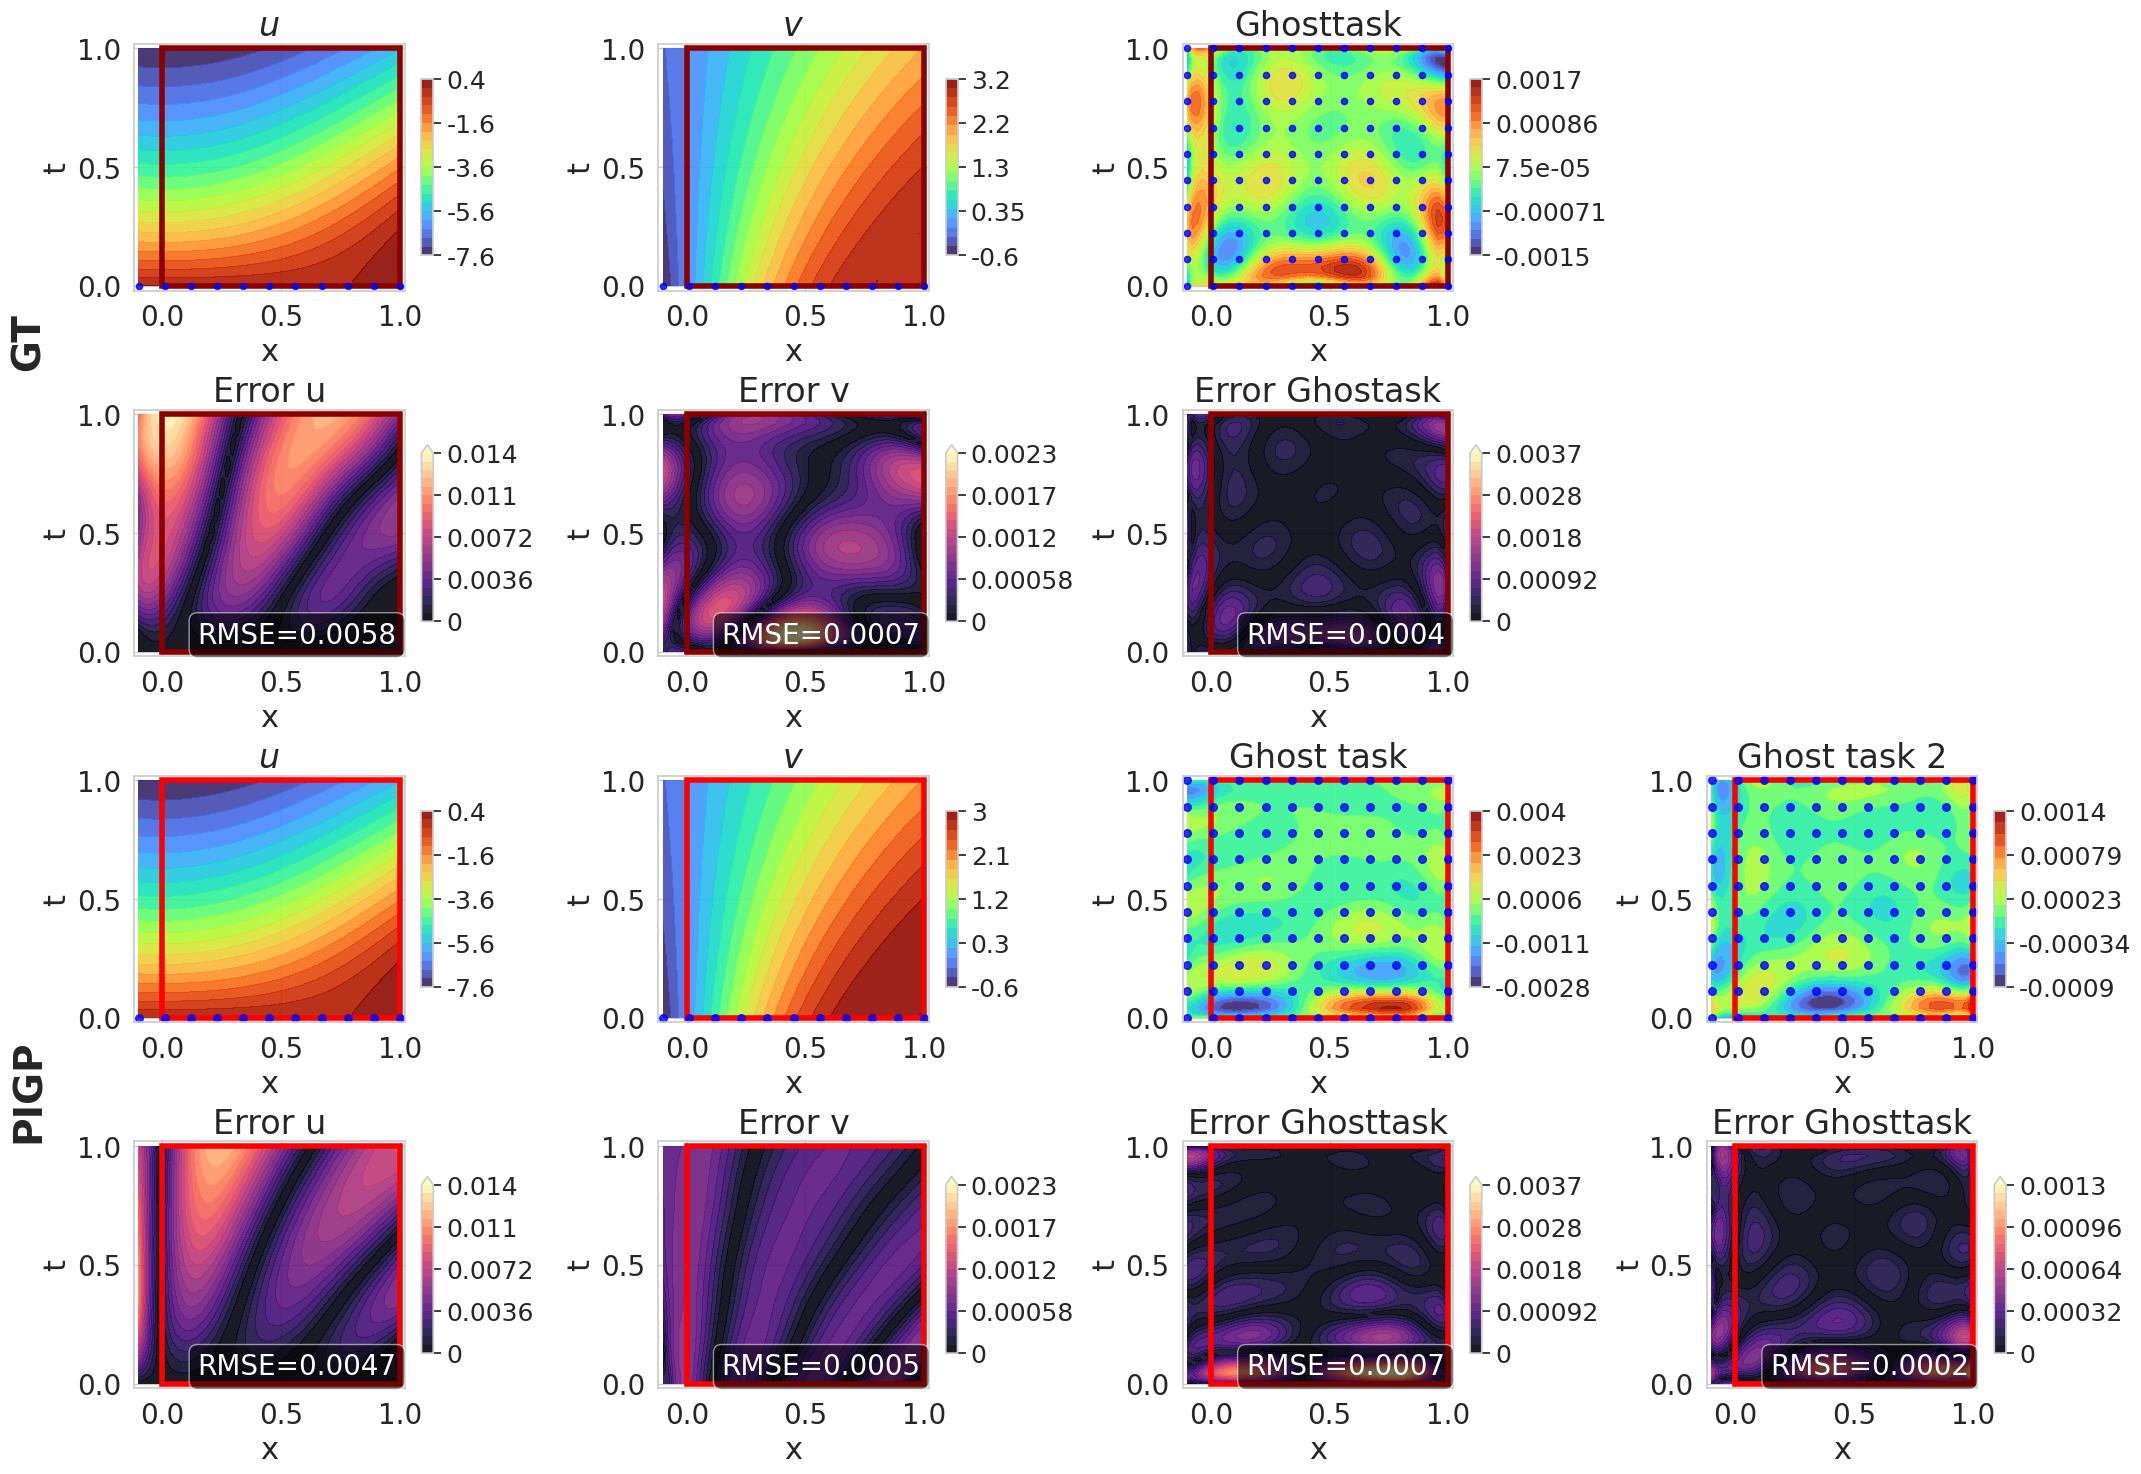

In [23]:
npoints      = 10
data_mode    = "yesextrapoint"   # "noextrapoint" or "yesextrapoint"
show_box     = True
share_errors = "taskwise"       # "taskwise" or "all"

def get_rmse(Z):
    return np.sqrt((np.array(Z)**2).sum()/(Z.flatten()).shape[0])


n_test_t = 51
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker


def style_cbar(cbar, surf, n_ticks=5):
    """Paper-ready colorbar: few ticks, 2 significant digits, no
    scientific-notation offset header floating in the figure."""
    vmin, vmax = surf.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2g}"))
    cbar.ax.yaxis.get_offset_text().set_visible(False)
    cbar.ax.tick_params(labelsize=18)


data_dir = os.path.join(output_data_ex1, "forward")

# ── GT ────────────────────────────────────────────────────────────────────────
data_gt    = load_run(data_dir, f"Ex1_n{npoints}_GT_{data_mode}.npz")
n_test_x_gt = len(data_gt.mean[data_gt.test_x[:,-1] == 0]) // n_test_t

u_gt   = data_gt.mean[data_gt.test_x[:,-1] == 0].reshape(n_test_x_gt, n_test_t)
v_gt   = data_gt.mean[data_gt.test_x[:,-1] == 1].reshape(n_test_x_gt, n_test_t)
GT_gt  = data_gt.mean[data_gt.test_x[:,-1] == 2].reshape(n_test_x_gt, n_test_t)
eu_gt  = u_gt  - data_gt.test_y[data_gt.test_x[:,-1] == 0].reshape(n_test_x_gt, n_test_t)
ev_gt  = v_gt  - data_gt.test_y[data_gt.test_x[:,-1] == 1].reshape(n_test_x_gt, n_test_t)
eGT_gt = GT_gt.copy()
x_gt   = data_gt.test_x[:,0][data_gt.test_x[:,-1] == 2].reshape(n_test_x_gt, n_test_t)
y_gt   = data_gt.test_x[:,1][data_gt.test_x[:,-1] == 2].reshape(n_test_x_gt, n_test_t)

# ── PIGP ──────────────────────────────────────────────────────────────────────
data_pigp    = load_run(data_dir, f"Ex1_n{npoints}_PIGP_{data_mode}.npz")
n_test_x_pigp = len(data_pigp.mean[data_pigp.test_x[:,-1] == 0]) // n_test_t

u_pigp    = data_pigp.mean[data_pigp.test_x[:,-1] == 0].reshape(n_test_x_pigp, n_test_t)
v_pigp    = data_pigp.mean[data_pigp.test_x[:,-1] == 1].reshape(n_test_x_pigp, n_test_t)
GT_pigp   = data_pigp.mean[data_pigp.test_x[:,-1] == 2].reshape(n_test_x_pigp, n_test_t)
GT2_pigp  = data_pigp.mean[data_pigp.test_x[:,-1] == 3].reshape(n_test_x_pigp, n_test_t)
eu_pigp   = u_pigp  - data_pigp.test_y[data_pigp.test_x[:,-1] == 0].reshape(n_test_x_pigp, n_test_t)
ev_pigp   = v_pigp  - data_pigp.test_y[data_pigp.test_x[:,-1] == 1].reshape(n_test_x_pigp, n_test_t)
eGT_pigp  = GT_pigp.copy()
eGT2_pigp = GT2_pigp.copy()
x_pigp    = data_pigp.test_x[:,0][data_pigp.test_x[:,-1] == 2].reshape(n_test_x_pigp, n_test_t)
y_pigp    = data_pigp.test_x[:,1][data_pigp.test_x[:,-1] == 2].reshape(n_test_x_pigp, n_test_t)

# ── shared error colour limits (abs errors, vmin=0) ───────────────────────────
# GT error panels: k=3,4,5  →  column = k-3
# PIGP error panels: k=4,5,6,7  →  column = k-4
box_gt   = (x_gt   >= 0) & (x_gt   <= 1)  # t is always [0,1], so only x needs masking
box_pigp = (x_pigp >= 0) & (x_pigp <= 1)




if share_errors == "all":
    vmax_e = [float(max(abs(eu_gt[box_gt]).max(), abs(ev_gt[box_gt]).max(), abs(eGT_gt[box_gt]).max(),
                        abs(eu_pigp[box_pigp]).max(), abs(ev_pigp[box_pigp]).max(), abs(eGT_pigp[box_pigp]).max(), abs(eGT2_pigp[box_pigp]).max()))] * 4
else:  # taskwise: same column shares vmax between GT and PIGP error rows
    vmax_e = [float(max(abs(eu_gt)[box_gt].max(),   abs(eu_pigp)[box_pigp].max())),
           float(max(abs(ev_gt)[box_gt].max(),   abs(ev_pigp)[box_pigp].max())),
           float(max(abs(eGT_gt)[box_gt].max(),  abs(eGT_pigp)[box_pigp].max())),
           float(abs(eGT2_pigp)[box_pigp].max())]

# ── figure ────────────────────────────────────────────────────────────────────
# rows 0-1: GT  (col 3 off, GT has no GT2 task)
# rows 2-3: PIGP
fig, axes = plt.subplots(4, 4, figsize=(21, 15))#, constrained_layout=True)
fig.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.05, hspace=0.45, wspace=0.55)
axes[0, 3].axis("off")
axes[1, 3].axis("off")

plots_gt = [
    (u_gt,         r"$u$",        "turbo", 0),
    (v_gt,         r"$v$",        "turbo", 1),
    (GT_gt,        "Ghosttask",  "turbo", 2),
    (abs(eu_gt),   "Error u",     "magma",   3),
    (abs(ev_gt),   "Error v",     "magma",   4),
    (abs(eGT_gt),  "Error Ghostask",    "magma",   5),
]
plots_pigp = [
    (u_pigp,          r"$u$",         "turbo", 0),
    (v_pigp,          r"$v$",         "turbo", 1),
    (GT_pigp,         "Ghost task",   "turbo", 2),
    (GT2_pigp,        "Ghost task 2", "turbo", 3),
    (abs(eu_pigp),    "Error u",      "magma",   4),
    (abs(ev_pigp),    "Error v",      "magma",   5),
    (abs(eGT_pigp),   "Error Ghosttask",     "magma",   6),
    (abs(eGT2_pigp),  "Error Ghosttask",    "magma",   7),
]

gt_axes = [axes[0,0], axes[0,1], axes[0,2],
           axes[1,0], axes[1,1], axes[1,2]]

for ax, (Z, title, cmap, k) in zip(gt_axes, plots_gt):
    is_error = k >= 3
    if is_error:
        col = k - 3
        levels = np.linspace(0, vmax_e[col], 21)
        surf = ax.contourf(x_gt, y_gt, Z, levels=levels, cmap=cmap, alpha=0.9, extend="max")
        ax.set_xlim(-.12, 1.02)
        ax.set_ylim(-.02, 1.02)
        ax.text(0.97, 0.03, f"RMSE={get_rmse(Z[box_gt]):.4f}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=20, color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.55))
    else:
        surf = ax.contourf(x_gt, y_gt, Z, cmap=cmap, levels=20, alpha=0.9)
        ax.set_xlim(-.12, 1.02)
        ax.set_ylim(-.02, 1.02)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)
    style_cbar(cbar, surf)
    if show_box:
        ax.add_patch(Rectangle((0, 0), 1, 1, linewidth=4, edgecolor="darkred", facecolor="none"))
    if not is_error:
        mask = data_gt.train_x[:,-1] == k
        ax.scatter(data_gt.train_x[mask, 0], data_gt.train_x[mask, 1], color="blue", s=20, alpha=0.8)
   
        
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("t", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)

for ax, (Z, title, cmap, k) in zip(axes[2:].flat, plots_pigp):
    is_error = k >= 4
    if is_error:
        col = k - 4
        levels = np.linspace(0, vmax_e[col], 21)
        surf = ax.contourf(x_pigp, y_pigp, Z, levels=levels, cmap=cmap, alpha=0.9, extend="max")
        ax.set_xlim(-.12, 1.02)
        ax.set_ylim(-.02, 1.02)
        ax.text(0.97, 0.03, f"RMSE={get_rmse(Z[box_pigp]):.4f}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=20, color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.55))
    else:
        surf = ax.contourf(x_pigp, y_pigp, Z, cmap=cmap, levels=20, alpha=0.9)
        ax.set_xlim(-.12, 1.02)
        ax.set_ylim(-.02, 1.02)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)
    style_cbar(cbar, surf)

    if show_box:
        ax.add_patch(Rectangle((0, 0), 1, 1, linewidth=4, edgecolor="red", facecolor="none"))
    if not is_error:
        mask = data_pigp.train_x[:,-1] == k
        ax.scatter(data_pigp.train_x[mask, 0], data_pigp.train_x[mask, 1], color="blue", s=30, alpha=0.8)
   # elif k in (6, 7):
        
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("t", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)
fig.text(0.02, 0.75, "GT",   va="center", ha="center", fontsize=28, fontweight="bold", rotation=90)
fig.text(0.02, 0.25, "PIGP", va="center", ha="center", fontsize=28, fontweight="bold", rotation=90)
#fig.suptitle(f"Forward — {data_mode}, n={npoints}", fontsize=28)
plt.savefig(os.path.join(save_dir, f"Ex1_forward.pdf"), bbox_inches="tight")

In [22]:
# grid posteriors: not interesting
def fwhm(x, y, level=0.5):
    """Full width at `level` of the peak of y (y assumed max-normalized, peak=1).
    Walks out from the global maximum until y drops below `level`, then linearly
    interpolates the crossing point for sub-grid precision."""
    x = np.asarray(x)
    y = np.asarray(y)
    i_max = int(np.argmax(y))

    i_left = i_max
    while i_left > 0 and y[i_left - 1] >= level:
        i_left -= 1
    if i_left == 0:
        x_left = x[0]
    else:
        x0, x1 = x[i_left - 1], x[i_left]
        y0, y1 = y[i_left - 1], y[i_left]
        x_left = x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    i_right = i_max
    while i_right < len(y) - 1 and y[i_right + 1] >= level:
        i_right += 1
    if i_right == len(y) - 1:
        x_right = x[-1]
    else:
        x0, x1 = x[i_right], x[i_right + 1]
        y0, y1 = y[i_right], y[i_right + 1]
        x_right = x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    return float(x_right - x_left)


sigma = .2
modes = ["GT", "PIGP", "Bayes"]
styles = ["-", "--", "-."]


#plt.figure()
for extra in ["yes", "no"]:
    for npoints in [10]:#, 5, 10]:
        for k in range(2): #3 mit bayes
            path = os.path.join(base_dir,  "Experiment1_Pedagogical", "grid", "output", f"{extra}extraGTsigma_inverse_extra")
    
            mode = modes[k]
            style = styles[k]
            fname = f"{mode}_n{npoints}_sigma{sigma:.2f}.npz"
            data = load_run(path, fname)
           
            mll_reshaped = data.mll_values.reshape(len(data.a_vals), len(data.ls_vals), len(data.A_vals))
           
            marginal =  jax.scipy.special.logsumexp(mll_reshaped, axis=(1, 2))
            marginal = jnp.exp(marginal - jnp.max(marginal))
            width = fwhm(data.a_vals, marginal)
            plt.plot(data.a_vals, marginal,  style, label = f"{extra}_{modes[k]} (FWHM={width:.3f})")
plt.legend(fontsize = 14)
        
plt.xlim(1, 3)
#plt.legend()
plt.xlabel("a")
plt.ylabel("posterior")
#plt.ylim(-2e5, 5)

#plt.plot(a_vals, (a_marginal-jnp.min(a_marginal)))
#plt.yscale("log")
#plt.savefig(os.path.join(base_dir, "Ex1_grid.pdf"))

FileNotFoundError: [Errno 2] No such file or directory: '/home/johanna/Documents/PhD/project/github/GhostTasking/Experiment1_Pedagogical/grid/output/yesextraGTsigma_inverse_extra/GT_n10_sigma0.20.npz'